# RecruitAI — Notebook 1: EDA and Preprocessing

This notebook performs **Exploratory Data Analysis (EDA)** on the Kaggle Resume Dataset and produces a cleaned version for model training.

**Dataset:** [gauravduttakiit/resume-dataset](https://www.kaggle.com/datasets/gauravduttakiit/resume-dataset)  
**Input:** `data/resume_dataset.csv`  
**Output:** `data/resume_dataset_cleaned.csv`

---
## Steps
1. Imports  
2. Load dataset  
3. Shape, dtypes, null check, category distribution  
4. Visualise category distribution  
5. Sample raw resume text  
6. Text cleaning function  
7. Apply cleaning — before/after  
8. Token length distribution  
9. Word clouds per top-5 categories  
10. Save cleaned dataset  

## Cell 1 — Imports

In [ ]:
!pip install wordcloud

In [3]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

STOP_WORDS = set(stopwords.words('english'))

# Matplotlib dark style
plt.rcParams.update({
    'figure.facecolor': '#0A0F1E',
    'axes.facecolor':   '#111827',
    'axes.edgecolor':   '#1F2937',
    'axes.labelcolor':  '#9CA3AF',
    'xtick.color':      '#6B7280',
    'ytick.color':      '#6B7280',
    'text.color':       '#F9FAFB',
    'grid.color':       '#1F2937',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

print('✓ Imports complete')

✓ Imports complete


## Cell 2 — Load Dataset

Expect two columns: **`Category`** and **`Resume`**.

In [8]:
DATA_PATH = 'data/resume_dataset.csv'

assert os.path.exists(DATA_PATH), (
    f"Dataset not found at {DATA_PATH}.\n"
    "Download from https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset"
    " and place resume_dataset.csv in the notebook/data/ folder."
)

df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} resumes')
print(f'Columns: {list(df.columns)}')
df.head(3)

Loaded 2,484 resumes
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


## Cell 3 — Shape, dtypes, null check, value_counts on Category

In [9]:
print('=== Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Null Values ===')
print(df.isnull().sum())

print('\n=== Category Distribution ===')
cat_counts = df['Category'].value_counts()
print(cat_counts.to_string())
print(f'\nTotal unique categories: {df["Category"].nunique()}')

=== Shape ===
Rows: 2,484  |  Columns: 4

=== Data Types ===
ID              int64
Resume_str     object
Resume_html    object
Category       object
dtype: object

=== Null Values ===
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

=== Category Distribution ===
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO  

## Cell 4 — Visualise Category Distribution

A horizontal bar chart shows how many resumes belong to each category. This helps identify class imbalances that may affect model evaluation.

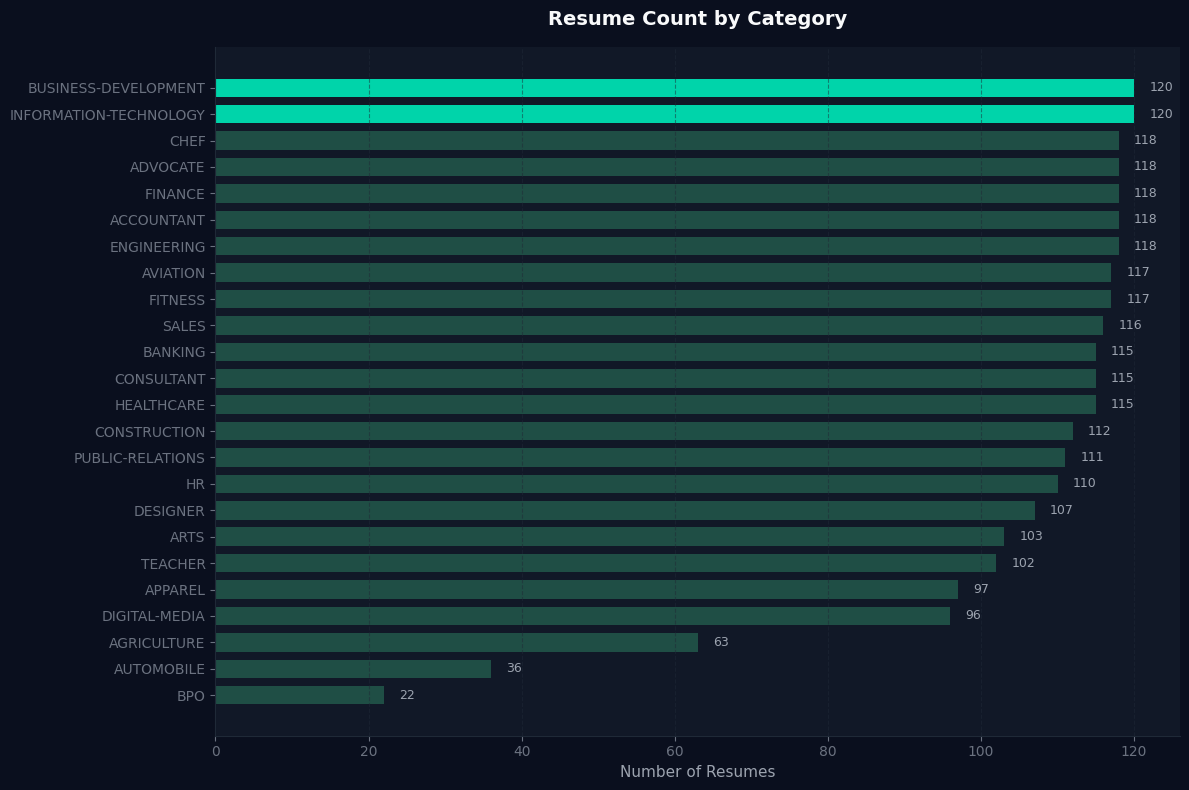

Chart saved to data/category_distribution.png


In [10]:
cat_counts_sorted = cat_counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#00D4AA' if v == cat_counts_sorted.max() else '#1F4E45'
          for v in cat_counts_sorted.values]

bars = ax.barh(cat_counts_sorted.index, cat_counts_sorted.values, color=colors, height=0.7)

for bar, val in zip(bars, cat_counts_sorted.values):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', color='#9CA3AF', fontsize=9)

ax.set_xlabel('Number of Resumes', fontsize=11)
ax.set_title('Resume Count by Category', fontsize=14, fontweight='bold', color='#F9FAFB', pad=16)
ax.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to data/category_distribution.png')

## Cell 5 — Sample Raw Resume Text

Inspect a few raw resume entries to understand text quality and noise level before cleaning.

In [11]:
sample = df.sample(3, random_state=42)
for _, row in sample.iterrows():
    resume_col = 'Resume' if 'Resume' in df.columns else df.columns[1]
    print(f'\n{'='*60}')
    print(f'Category: {row["Category"]}')
    print(f'Text snippet (first 400 chars):')
    print(str(row[resume_col])[:400])
    print(f'Total length: {len(str(row[resume_col]))} chars')


Category: TEACHER
Text snippet (first 400 chars):
           Kpandipou    Koffi         Summary      Compassionate teaching professional delivering exemplary support and assistance to teachers and students. Display exceptional Communication and problem solving skills.  Experience in office administration and public speaking. Attentive and adaptable, skilled in management of classroom operations. Effective in leveraging student feedback to create 
Total length: 5576 chars

Category: DIGITAL-MEDIA
Text snippet (first 400 chars):
         DIRECTOR OF DIGITAL TRANSFORMATION       Executive Profile     Digital and print media professional  and consultant with a strong vision to develop new projects and specialist in business development. Strong management skills and leading teams. Result oriented. Passionate and experienced in product and audience development, analytic tools, emerging technologies and their applications in t
Total length: 6450 chars

Category: CONSTRUCTION
Text snippet (fi

## Cell 6 — Text Cleaning Function

A robust cleaning pipeline:
- Lowercase all text
- Remove URLs, email addresses, and phone numbers
- Remove special characters and punctuation
- Collapse whitespace
- Remove NLTK English stopwords

BERT is context-aware and handles stopwords differently from TF-IDF, but removing them reduces noise in shorter texts.

In [12]:
# Compiled regex patterns for performance
_URL_RE    = re.compile(r'https?://\S+|www\.\S+')
_EMAIL_RE  = re.compile(r'\b[\w.+-]+@[\w-]+\.[a-zA-Z]{2,}\b')
_PHONE_RE  = re.compile(r'(\+?\d[\d\s\-().]{7,}\d)')
_SPECIAL_RE = re.compile(r'[^a-z0-9\s]')
_SPACE_RE  = re.compile(r'\s+')


def clean_text(text: str) -> str:
    """Full cleaning pipeline for a single resume string."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = _URL_RE.sub(' ', text)
    text = _EMAIL_RE.sub(' ', text)
    text = _PHONE_RE.sub(' ', text)
    text = _SPECIAL_RE.sub(' ', text)
    text = _SPACE_RE.sub(' ', text).strip()
    # Remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)


# Quick unit test
raw = 'John Smith — Sr. Data Scientist | john@email.com | +1-555-123-4567 | linkedin.com/in/john'
cleaned = clean_text(raw)
print(f'Input : {raw}')
print(f'Output: {cleaned}')
print('\n✓ clean_text() working correctly')

Input : John Smith — Sr. Data Scientist | john@email.com | +1-555-123-4567 | linkedin.com/in/john
Output: john smith sr data scientist linkedin com john

✓ clean_text() working correctly


## Cell 7 — Apply Cleaning — Before / After Comparison

Apply the cleaning function to all resumes using `pandas.Series.map()` for vectorised performance.

In [13]:
resume_col = 'Resume' if 'Resume' in df.columns else df.columns[1]

print(f'Cleaning {len(df):,} resumes using column "{resume_col}"…')
df['Resume_str'] = df[resume_col].map(clean_text)

# Drop any empty results
original_len = len(df)
df = df[df['Resume_str'].str.len() > 50].reset_index(drop=True)
print(f'Dropped {original_len - len(df)} near-empty entries. Remaining: {len(df):,}')

# Before/after example
idx = 0
print(f'\n--- BEFORE (first 300 chars) ---')
print(str(df[resume_col].iloc[idx])[:300])
print(f'\n--- AFTER (first 300 chars) ---')
print(df['Resume_str'].iloc[idx][:300])
print(f'\nLength before: {len(str(df[resume_col].iloc[idx]))} | After: {len(df["Resume_str"].iloc[idx])}')

Cleaning 2,484 resumes using column "Resume_str"…
Dropped 1 near-empty entries. Remaining: 2,483

--- BEFORE (first 300 chars) ---
hr administrator marketing associate hr administrator summary dedicated customer service manager 15 years experience hospitality customer service management respected builder leader customer focused teams strives instill shared enthusiastic commitment customer service highlights focused customer sat

--- AFTER (first 300 chars) ---
hr administrator marketing associate hr administrator summary dedicated customer service manager 15 years experience hospitality customer service management respected builder leader customer focused teams strives instill shared enthusiastic commitment customer service highlights focused customer sat

Length before: 4348 | After: 4348


## Cell 8 — Token Length Distribution

Understanding the token distribution helps choose an appropriate max-length strategy for BERT (which caps at 512 tokens). Most resumes should fit within this limit.

=== Token Length Statistics ===
count    2483.0
mean      614.5
std       272.1
min        83.0
25%       500.0
50%       574.0
75%       708.0
max      3620.0

Resumes with >512 tokens: 1748 (70.4%)


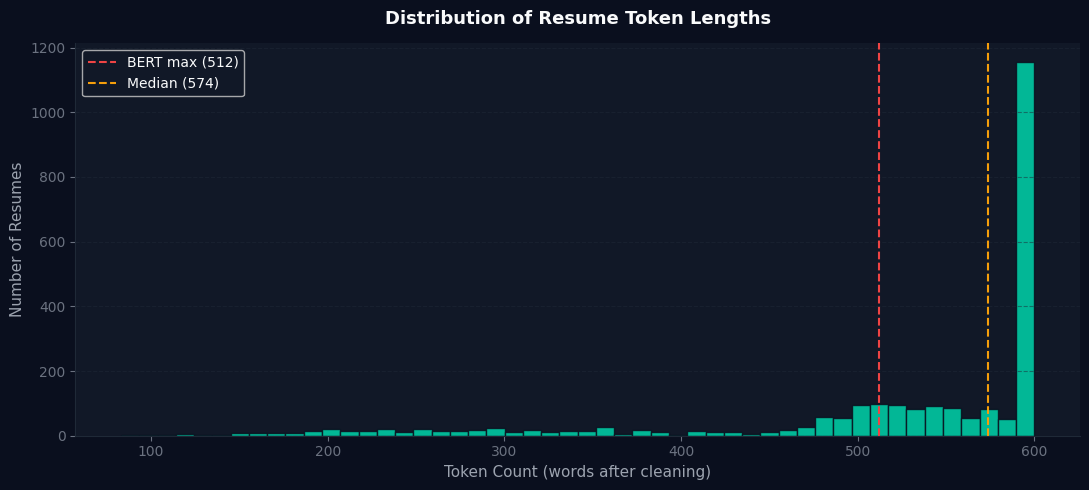

In [14]:
df['token_count'] = df['Resume_str'].str.split().str.len()

print('=== Token Length Statistics ===')
print(df['token_count'].describe().round(1).to_string())
print(f'\nResumes with >512 tokens: {(df["token_count"] > 512).sum()} '
      f'({(df["token_count"] > 512).mean():.1%})')

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df['token_count'].clip(upper=600), bins=50, color='#00D4AA', alpha=0.85, edgecolor='#0A0F1E')
ax.axvline(512, color='#EF4444', linewidth=1.5, linestyle='--', label='BERT max (512)')
ax.axvline(df['token_count'].median(), color='#F59E0B', linewidth=1.5,
           linestyle='--', label=f'Median ({df["token_count"].median():.0f})')

ax.set_xlabel('Token Count (words after cleaning)', fontsize=11)
ax.set_ylabel('Number of Resumes', fontsize=11)
ax.set_title('Distribution of Resume Token Lengths', fontsize=13, fontweight='bold', color='#F9FAFB', pad=14)
ax.legend(fontsize=10)
ax.grid(axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Word Cloud per Top 5 Categories

Word clouds reveal the most distinctive vocabulary in each category, helping us understand what terms drive similarity scores.

Generating word clouds for: ['INFORMATION-TECHNOLOGY', 'BUSINESS-DEVELOPMENT', 'ADVOCATE', 'CHEF', 'ENGINEERING']


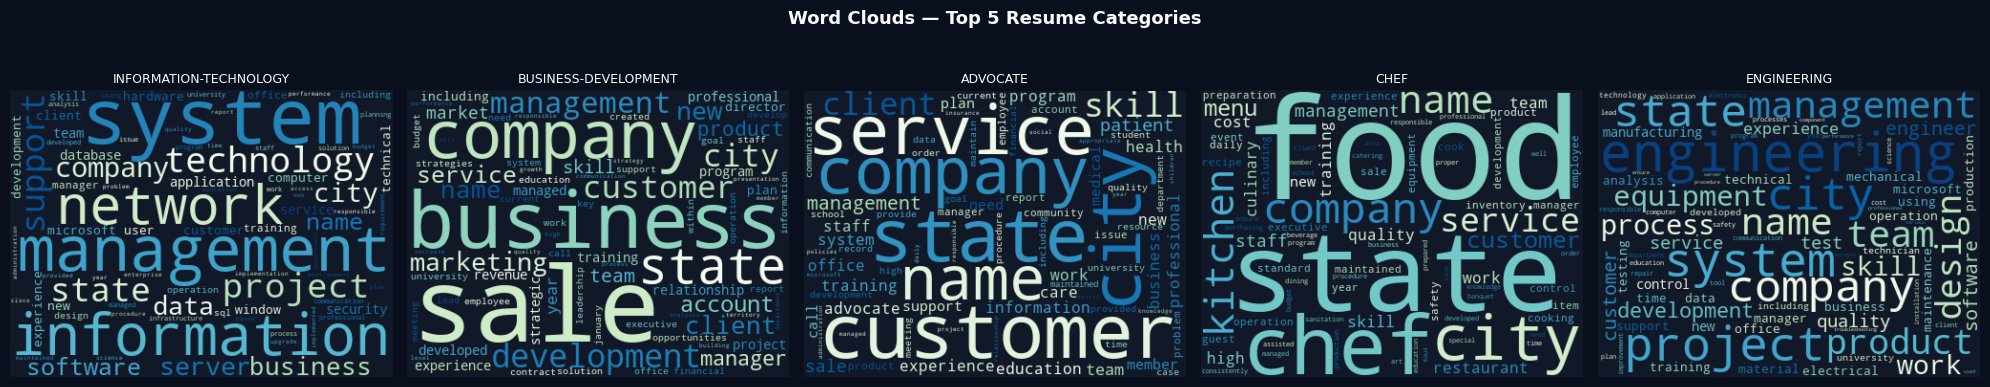

Word clouds saved to data/wordclouds_top5.png


In [15]:
top5_cats = cat_counts.head(5).index.tolist()
print(f'Generating word clouds for: {top5_cats}')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, cat in zip(axes, top5_cats):
    text = ' '.join(df[df['Category'] == cat]['Resume_str'].tolist())
    wc = WordCloud(
        width=400, height=300,
        background_color='#111827',
        colormap='GnBu',
        max_words=80,
        prefer_horizontal=0.9,
        collocations=False,
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(cat, fontsize=9, color='#F9FAFB', pad=6)

fig.suptitle('Word Clouds — Top 5 Resume Categories', fontsize=13,
             fontweight='bold', color='#F9FAFB', y=1.02)
plt.tight_layout()
plt.savefig('data/wordclouds_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Word clouds saved to data/wordclouds_top5.png')

## Cell 10 — Save Cleaned Dataset

Save the processed dataframe to CSV. This file is the input for `02_Model_Training_and_Evaluation.ipynb`.

In [16]:
OUTPUT_PATH = 'data/resume_dataset_cleaned.csv'

df[['Category', 'Resume_str']].to_csv(OUTPUT_PATH, index=False)

file_size_kb = os.path.getsize(OUTPUT_PATH) / 1024
print(f'✓ Saved cleaned dataset to: {OUTPUT_PATH}')
print(f'  Rows    : {len(df):,}')
print(f'  Columns : Category, Resume_str')
print(f'  Size    : {file_size_kb:.1f} KB')
print(f'  Categories: {df["Category"].nunique()}')

print('\n=== Sample of cleaned dataset ===')
df[['Category', 'Resume_str']].head(3)

✓ Saved cleaned dataset to: data/resume_dataset_cleaned.csv
  Rows    : 2,483
  Columns : Category, Resume_str
  Size    : 12214.1 KB
  Categories: 24

=== Sample of cleaned dataset ===


,Category,Resume_str
0,HR,hr administrator marketing associate hr admini...
1,HR,hr specialist us hr operations summary versati...
2,HR,hr director summary 20 years experience recrui...
